In [2]:
from datasets import load_dataset

ds = load_dataset("lance-format/stanford-cars-lance", split="train", cache_dir="./Data/Datasets")
split = ds.train_test_split(test_size=0.10, seed=42)

train_ds = split["train"]
val_ds = split["test"]

print("Train:", len(train_ds))
print("Validation:", len(val_ds))

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Train: 7329
Validation: 815


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from Dataloader import TTIDataset
from Text_encoder import Text_encoder
from UNET import UNet
from CosineNoiseScheduler import CosineNoiseScheduler
from Token.TTI_Tokenizer import TTITokenizer
from DefussionBlock import SinusoidalTimeEmbedding, TimeEmbedding

import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [5]:
BATCH_SIZE = 8
IMAGE_SIZE = 64

VOCAB_SIZE = 4001
MAX_LENGTH = 64
TEXT_DIM = 512

TIME_DIM = 256

N_HEAD = 8
N_LAYERS = 6

TIMESTEPS = 1000

LEARNING_RATE = 1e-4
EPOCHS = 50

DROPOUT = 0.1

GRAD_CLIP = 1.0

CHECKPOINT_PATH = "checkpoints/TTI.pt"

In [6]:
tokenizer = TTITokenizer("Token/bpe_tokenizer.json",max_length=MAX_LENGTH)

train_dataset = TTIDataset(train_ds,tokenizer)
val_dataset = TTIDataset(val_ds,tokenizer)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True)

In [7]:
batch = next(iter(train_loader))

print("Image:", batch["image"].shape)
print("Input IDs:", batch["input_ids"].shape)
print("Attention:", batch["attention_mask"].shape)

Image: torch.Size([8, 3, 64, 64])
Input IDs: torch.Size([8, 64])
Attention: torch.Size([8, 64])


In [8]:
tokenizer = TTITokenizer("Token/bpe_tokenizer.json",max_length=MAX_LENGTH)
vocab_size = tokenizer.vocab_size

text_encoder = Text_encoder(n_head=N_HEAD,n_layer=N_LAYERS,num_embeddings=vocab_size,embedding_dim=TEXT_DIM,max_length=MAX_LENGTH,dropout=DROPOUT).to(device)
unet = UNet(time_dim=TIME_DIM,text_dim=TEXT_DIM).to(device)
time_embedding = SinusoidalTimeEmbedding(TIME_DIM).to(device)
time_encoder = TimeEmbedding(TIME_DIM,TIME_DIM).to(device)

In [9]:
noise_scheduler = CosineNoiseScheduler(timesteps=TIMESTEPS)

In [10]:
optimizer = torch.optim.AdamW(list(unet.parameters()) + list(text_encoder.parameters()),lr=LEARNING_RATE,betas=(0.9,0.999),weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)

In [11]:
batch = next(iter(train_loader))

images = batch["image"].to(device)
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

with torch.no_grad():
    text_features = text_encoder(input_ids,attention_mask)

print("Images:", images.shape)
print("Text:", text_features.shape)

Images: torch.Size([8, 3, 64, 64])
Text: torch.Size([8, 64, 512])


In [12]:
t = torch.randint(0,TIMESTEPS,(images.size(0),),device=device)
noisy_images, noise = noise_scheduler.add_noise(images,t)

print("Clean:", images.shape)
print("Noisy:", noisy_images.shape)
print("Noise:", noise.shape)

Clean: torch.Size([8, 3, 64, 64])
Noisy: torch.Size([8, 3, 64, 64])
Noise: torch.Size([8, 3, 64, 64])


In [13]:
predicted_noise = unet(noisy_images,t,text_features)

print(predicted_noise.shape)

torch.Size([8, 3, 64, 64])


In [14]:
loss = F.mse_loss(predicted_noise,noise)

print("Loss:", loss.item())

Loss: 1.1049811840057373


In [15]:
optimizer.zero_grad()
loss.backward()
torch.nn.utils.clip_grad_norm_(unet.parameters(),GRAD_CLIP)

optimizer.step()

In [17]:
def load_checkpoint(unet, text_encoder, optimizer, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

    unet.load_state_dict(checkpoint["unet"])
    text_encoder.load_state_dict(checkpoint["text_encoder"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    unet.to(device)
    text_encoder.to(device)

    start_epoch = checkpoint["epoch"] + 1
    loss = checkpoint["loss"]

    print(f"Loaded checkpoint: {checkpoint_path}")
    print(f"Resuming from epoch: {start_epoch}")
    print(f"Previous loss: {loss:.5f}")

    return start_epoch


start_epoch = 0
if os.path.exists(CHECKPOINT_PATH):
    start_epoch = load_checkpoint(unet, text_encoder, optimizer, CHECKPOINT_PATH, device)
else:
    print("No existing checkpoint found — starting training from scratch.")


Loaded checkpoint: checkpoints/TTI.pt
Resuming from epoch: 56
Previous loss: 0.04386


In [ ]:
for epoch in range(start_epoch,EPOCHS):
    unet.train()
    text_encoder.train()
    total_loss = 0.0

    for batch in train_loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        text_features = text_encoder(input_ids,attention_mask)
        t = torch.randint(0,TIMESTEPS,(images.size(0),),device=device)
        noisy_images, noise = noise_scheduler.add_noise(images,t)
        predicted_noise = unet(noisy_images,t,text_features)
        loss = F.mse_loss(predicted_noise,noise)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(list(unet.parameters()) + list(text_encoder.parameters()),GRAD_CLIP)

        optimizer.step()
        total_loss += loss.item()

    lr_scheduler.step()
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.5f}")

In [ ]:
torch.save({"epoch": epoch,"unet": unet.state_dict(),"text_encoder": text_encoder.state_dict(),"optimizer": optimizer.state_dict(),"loss": avg_loss}, f"checkpoints/TTI.pt")

In [18]:
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

t=999 | x min=-3.900 max=4.026 mean=-0.007 std=0.992
t=750 | x min=-3.899 max=4.111 mean=0.016 std=0.940
t=500 | x min=-2.614 max=3.032 mean=0.057 std=0.780
t=250 | x min=-2.041 max=2.032 mean=0.067 std=0.583
t=100 | x min=-1.400 max=1.309 mean=0.070 std=0.487
t=50 | x min=-1.192 max=1.154 mean=0.072 std=0.467
t=0 | x min=-1.000 max=0.971 mean=0.072 std=0.459


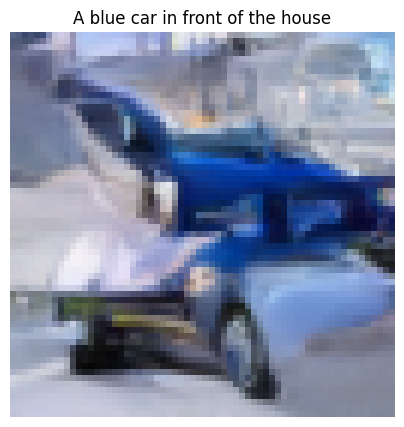

In [19]:
@torch.no_grad()
def generate_image(prompt, tokenizer, text_encoder, unet, scheduler, device, image_size=64):
    text_encoder.eval()
    unet.eval()

    encoded = tokenizer.encode_ids(prompt)
    input_ids = torch.tensor([encoded["input_ids"]], dtype=torch.long, device=device)
    attention_mask = torch.tensor([encoded["attention_mask"]], dtype=torch.long, device=device)

    text_features = text_encoder(input_ids, attention_mask)
    x = torch.randn(1, 3, image_size, image_size, device=device)

    for i in reversed(range(scheduler.timesteps)):
        t = torch.tensor([i], device=device)
        predicted_noise = unet(x, t, text_features)

        alpha_bar = scheduler.alpha_cumprod[i].to(device)
        sqrt_alpha_bar = torch.sqrt(alpha_bar)
        sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

        x0_pred = (x - sqrt_one_minus_alpha_bar * predicted_noise) / sqrt_alpha_bar
        x0_pred = x0_pred.clamp(-1, 1)

        if i > 0:
            alpha_bar_prev = scheduler.alpha_cumprod[i - 1].to(device)

            beta = scheduler.betas[i].to(device)
            alpha = scheduler.alphas[i].to(device)

            coef_x0 = (torch.sqrt(alpha_bar_prev) * beta / (1.0 - alpha_bar))
            coef_xt = (torch.sqrt(alpha) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar))

            mean = coef_x0 * x0_pred + coef_xt * x
            variance = (beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar))

            noise = torch.randn_like(x)
            x = mean + torch.sqrt(variance) * noise
        else:
            x = x0_pred

        if i in [999, 750, 500, 250, 100, 50, 0]:
            print(
                f"t={i} | "
                f"x min={x.min().item():.3f} "
                f"max={x.max().item():.3f} "
                f"mean={x.mean().item():.3f} "
                f"std={x.std().item():.3f}"
            )

    image = ((x.clamp(-1, 1) + 1) / 2)[0]
    image = image.permute(1, 2, 0).cpu()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(prompt)
    plt.show()

    return image

image = generate_image("A blue car in front of the house",tokenizer,text_encoder,unet,noise_scheduler,device)

In [34]:
@torch.no_grad()
def generate_image_with_process(prompt, tokenizer, text_encoder, unet, scheduler, device, image_size=64, save_every=50):
    text_encoder.eval()
    unet.eval()

    encoded = tokenizer.encode_ids(prompt)
    input_ids = torch.tensor([encoded["input_ids"]], dtype=torch.long, device=device)
    attention_mask = torch.tensor([encoded["attention_mask"]], dtype=torch.long, device=device)

    text_features = text_encoder(input_ids, attention_mask)

    x = torch.randn(1, 3, image_size, image_size, device=device)

    frames = []
    steps = []

    for i in reversed(range(scheduler.timesteps)):
        t = torch.tensor([i], dtype=torch.long, device=device)

        predicted_noise = unet(x, t, text_features)

        alpha_bar = scheduler.alpha_cumprod[i].to(device)
        sqrt_alpha_bar = torch.sqrt(alpha_bar)
        sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

        x0_pred = (x - sqrt_one_minus_alpha_bar * predicted_noise) / sqrt_alpha_bar
        x0_pred = x0_pred.clamp(-1, 1)

        if i > 0:
            alpha_bar_prev = scheduler.alpha_cumprod[i - 1].to(device)
            beta = scheduler.betas[i].to(device)
            alpha = scheduler.alphas[i].to(device)

            coef_x0 = torch.sqrt(alpha_bar_prev) * beta / (1.0 - alpha_bar)
            coef_xt = torch.sqrt(alpha) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

            mean = coef_x0 * x0_pred + coef_xt * x
            variance = beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

            noise = torch.randn_like(x)
            x = mean + torch.sqrt(variance) * noise
        else:
            x = x0_pred

        if i % save_every == 0 or i == 0:
            frame = (x.clamp(-1, 1) + 1) / 2
            frame = frame[0].permute(1, 2, 0).cpu().numpy()
            frames.append(frame)
            steps.append(i)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis("off")
    ax.set_title(f"Timestep: {steps[0]}")

    image_display = ax.imshow(frames[0])

    def update(frame_index):
        image_display.set_data(frames[frame_index])
        ax.set_title(f"Timestep: {steps[frame_index]}")
        return [image_display]

    animation = FuncAnimation(fig, update, frames=len(frames), interval=150, blit=True)

    plt.close(fig)

    return HTML(animation.to_jshtml())

In [ ]:
animation = generate_image_with_process(input("Enter a prompt: "),tokenizer,text_encoder,unet,noise_scheduler,device,image_size=64,save_every=25)

display(animation)